![logo](../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Investigating the variability of extreme rainfall events during the monsoon season in different forecasting systems

Production date: 30.04.2026

Produced by: Johanna Tjernström (METNorway), Johannes Langvatn (METNorway)

## 🌍 Use case: Investigating the probability of extreme precipitation events for the Indian subcontinent in different forecasting systems.

## ❓ Quality assessment question
* **How does the frequency and placement of extreme rainfall events vary between forecasting systems?**
* **How does the forecast skill, as determined by comparison with reanalysis, vary between different forecasting systems?**

During the summer monsoon many parts of the Indian subcontinent receive heavy rainfall, however, within that period there are both temporal and geographical variations in intensity ([Pattanaik, D.R. and Rajeevan, M. (2010) \[1\]](https://doi.org/10.1002/met.164)) . These fluctuations between wet and dry spells has the potential to impact agriculture, water resources and other infrastructure. ([Singh, D., Tsiang, M., Rajaratnam, B. et al. (2009) \[2\]](https://doi.org/10.1029/2009JD012795))

This notebook considers the probability of extreme precipitation events for the Indian subcontinent in different forecasting systems. Comparing their results, both spatially and the frequency of extreme rainfall events, between forecasting systems and evaluating them against ERA5. 

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* Some regions are identified to have increased probability of precipiation for a forecast length of two months, but there is varying skill in the different forecast models for 2 month 
* Using a multi model approach gives some signal, but the spatial placement of the strongest forecasted signal is shifted from its corresponding signal in the reanalysis
```

## 📋 Methodology

This notebook investigates monsoon onset by using total precipitation rate from [Seasonal forecast monthly statistics on single levels](https://doi.org/10.24381/cds.68dd14c3), this is integrated to total precipitation to later compare with data from [ERA5 Reanalysis](https://doi.org/10.24381/cds.adbb2d47).

To correctly identify the monsoon signal in each forecast model we define a treshold for extreme precipitation, and calculate the exceedence of this threshold for each model individually since the models have different climatologies.

The probability of exceedence of this treshold is then plotted against reanalysis and compared to check for skill.

**[](seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-1)**
 * Choose a region of interest, a selection of forecast systems and versions, and leadtimes to investigate
 * Choose a hindcast period (typically 1993-2016) to compute a climatology
 * Choose percentile for extreme precipitation
 * Total precipitation rate is converted to total precipitation for the forecast models

**[](seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-2)**
 * The exceedence of extreme precipitation per forecast model and the reanalysis is computed

**[](seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-3)**
 * The extreme precipitation is plotted for each forecast model, with exceedence in reanalysis also plotted for comparison

**[](seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-4)**

Key limitations:
Some models were disregarded due to discrepancies in data formatting in regards to time. The models chosen were selected based on their cohesion, and models that deviated from this shared structure were removed for ease of use. During this investigation several percentiles were tested, but 90% as "extreme rainfall" was chosen as this gave the best consistensy between the forecasting systems.


## 📈 Analysis and results

(seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-1)=
### 1. Download data, selecting region, and models of interest

Import packages and define functions needed for the analysis

In [30]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from c3s_eqc_automatic_quality_control import diagnostics, download, utils
import pandas as pd

def tprate_to_tp(dataarray):
    secs = []
    earlier_seconds = 0
    for ind in range(len(dataarray.leadtime)):
        seconds = int(dataarray.leadtime[ind]/(1e9))
        leadtime_seconds = seconds-earlier_seconds
        secs.append(leadtime_seconds)
        earlier_seconds = seconds
    secs = np.array(secs).reshape((6,1,1))
    # days_per_month = secs/(60*60*24)
    tp = (secs*dataarray)
    tp.attrs["units"] = "m"
    tp.attrs["long_name"] = "Monthly Total precipitation amount"
    return tp

Define the region of interest by giving a bounding box of north, west, south, east extent. Also choose the extreme perenctile treshold

In [3]:
bbox = [39, 66, 6, 99]
extreme_percentile = .90
kwargs = {
    "chunks": {"year": 1},
    "n_jobs": 1,   
}

Download the reanalysis for hindcast and forecast period

In [ ]:
dataset = "reanalysis-era5-single-levels-monthly-means"
era_request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["total_precipitation"],
    "year": [
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016",
    ],
    "month": [
        "05", "06", "07",
        "08", "09", "10"
    ],
    "time": ["00:00"],
    "data_format": "grib",
    "grid": "1/1",
    "download_format": "unarchived",
    "area": bbox
}
era5_hindcast = download.download_and_transform(
        dataset,
        era_request,
        **kwargs
)
era_request["year"] = ["2025"]
era5 = download.download_and_transform(
        dataset,
        era_request,
        **kwargs
)

Download the seasonal forecast models for the hindcast period

In [ ]:
dataset = "seasonal-monthly-single-levels"
hindcast_request = {
    "variable": ["total_precipitation"],
    "year": [
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016"
    ],
    "month": ["05"],
    "area": bbox,
    "grid": "1/1",
    "product_type": ["monthly_mean"],
    "leadtime_month": [
        "1", "2", "3", "4", "5", "6"
    ],
}

models = {
    "ecmwf": "51",
    #"ukmo": "604",
    "meteo_france": "9",
    "dwd": "22",
    "cmcc": "35",
    #"ncep": "2",
    #"jma": "3", 
    "eccc": "5", #4 is also an option
    #"bom": "2",
}
# "area": [3, -4, -1, 2]
hindcast_list = []


for model, system in models.items():
    print(model, system)
    request = hindcast_request
    request["system"] = system
    request["originating_centre"] = model
    da = download.download_and_transform(
        dataset,
        request,
        **kwargs
    )
    # convert tprate to total precipitation
    da["tp"] = tprate_to_tp(da.tprate)
    hindcast_list.append(da)

Download the seasonal forecast models for the forecast period

In [ ]:
forecast_request = {
    "variable": ["total_precipitation"],
    "year": ["2025"],
    "month": ["05"],
    "area": bbox,
    "grid": "1/1",
    "product_type": ["monthly_mean"],
    "leadtime_month": [
        "1", "2", "3", "4", "5", "6"
    ],
}

forecast_list = []
for model, system in models.items():
    print(model, system)
    request = forecast_request
    request["system"] = system
    request["originating_centre"] = model
    da = download.download_and_transform(
        dataset,
        request,
    )
    # convert tprate to total precipitation
    da["tp"] = tprate_to_tp(da.tprate)
    forecast_list.append(da)
    

(seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-2)=
### 2. Calculate model specific extreme precipitation

For each chosen leadtime, compute each model specific value of extreme precipitation including all hindcast realizations. Also compute the reanalysis treshold value

In [10]:
model_dict = {}
for model in hindcast_list:
    clim_list = []
    print(model.GRIB_centre,model.GRIB_centreDescription)
    for ind in range(len(model.leadtime)):
        clim_list.append(model.isel(leadtime=ind).tp.quantile(extreme_percentile, dim=["realization", "forecast_reference_time"]))
    model_dict[model.GRIB_centre] = xr.concat(clim_list, dim="leadtime")
total_month = len(model.leadtime)
model_dict["era5"] = []
for month in range(total_month):
    model_dict["era5"].append(era5_hindcast.isel(forecast_reference_time=range(0+month,96+month,total_month)).tp.quantile(extreme_percentile, dim=["forecast_reference_time"]))


era5_perc = xr.DataArray(data = model_dict["era5"], coords={
    "forecast_reference_time": era5.forecast_reference_time, "latitude": model_dict["era5"][0].latitude,
    "longitude": model_dict["era5"][0].longitude }, 
    name="tp", attrs = model_dict["era5"][0].attrs)

ecmf European Centre for Medium-Range Weather Forecasts
lfpw French Weather Service - Toulouse
edzw Offenbach
cnmc Rome
cwao Canadian Meteorological Service - Montreal


(seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-3)=
### 3. How often and where does percentile exceeding precipitation occur?

First the exceedence in the reanalysis is computed, then the exceedence of the forecast systems are computed. This is then plotted together, with the colorbar showing the probability of extreme precipitation from the forecast model, and the red hatches shows where there is extreme precipiation in the reanalysis.
Lastly the combined (mean) probability of extreme precipitation is plotted compared to the reanalysis

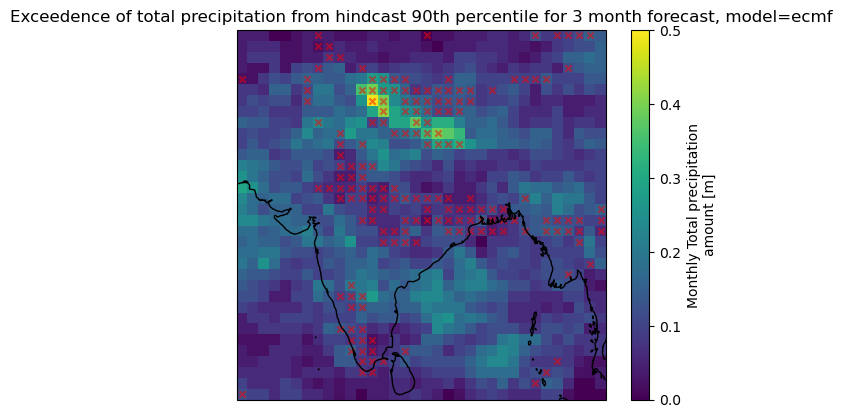

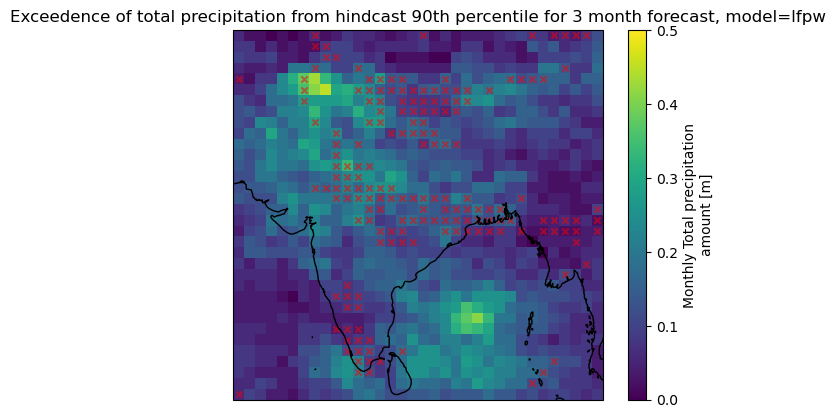

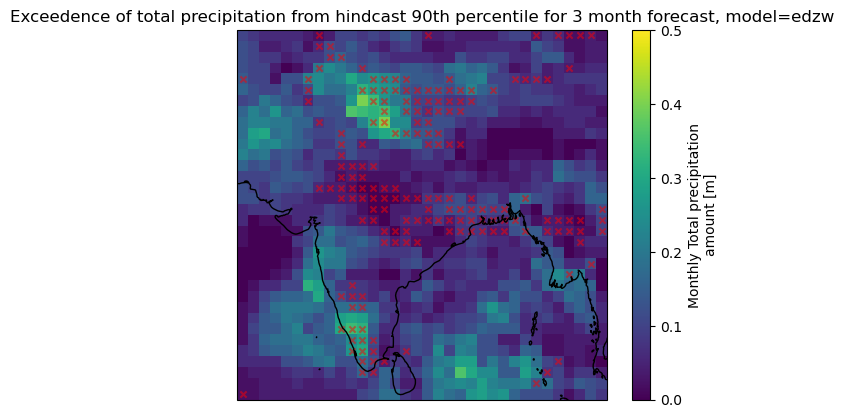

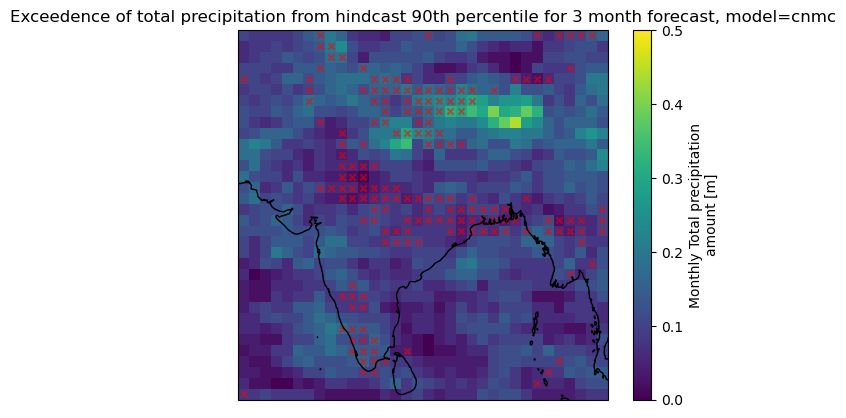

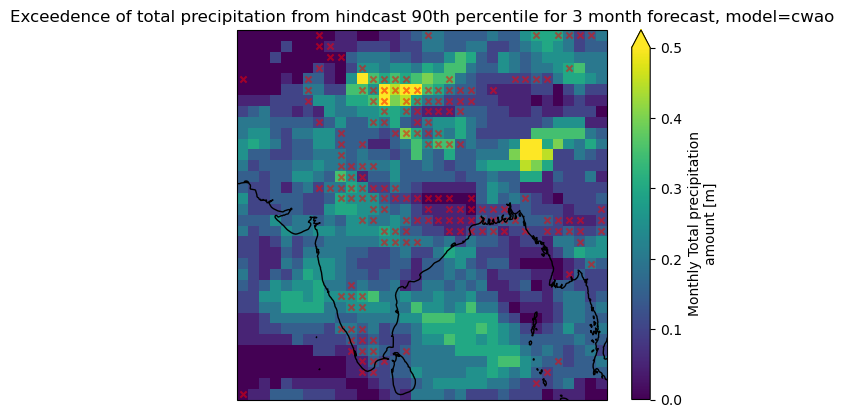

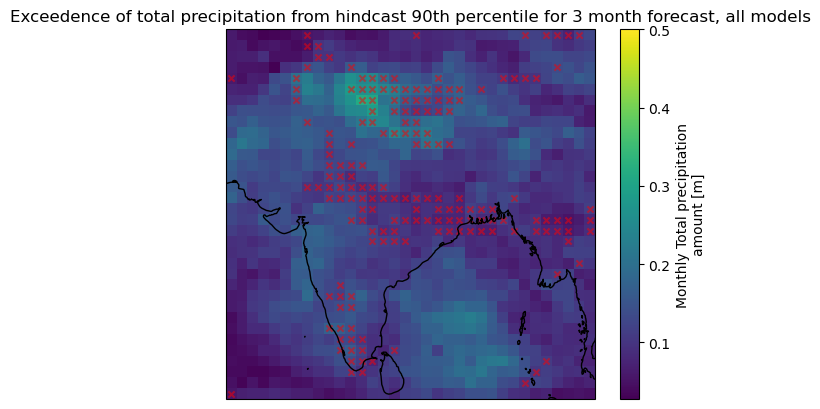

In [32]:
leadtime= 2
total = 0

da_mask = (era5.tp > era5_perc).isel(forecast_reference_time=leadtime)
mask_np = da_mask.compute()
lat_coords = mask_np["latitude"].values
lon_coords = mask_np["longitude"].values

lat_points, lon_points = np.where(mask_np.values == 1)

lat_selected = lat_coords[lat_points]
lon_selected = lon_coords[lon_points]

for model in da_list:
    ax = plt.subplot(projection=ccrs.PlateCarree())
    model_exceedence = (model.tp.isel(leadtime=leadtime) > model_dict[model.GRIB_centre].isel(leadtime=leadtime)).mean(dim="realization")
    (model_exceedence).plot(ax=ax, vmax=.5)
    total += model_exceedence
    
    ax.scatter(lon_selected, lat_selected, marker="x", color="red", s=20, alpha=.5)
    ax.coastlines()
    plt.title(f"Exceedence of total precipitation from hindcast 90th percentile for {leadtime+1} month forecast, model={model.GRIB_centre}")
    plt.show()
    
ax = plt.subplot(projection=ccrs.PlateCarree())
(total/len(da_list)).plot(ax=ax, vmax=.5)
ax.scatter(lon_selected, lat_selected, marker="x", color="red", s=20, alpha=.5)
ax.coastlines()
plt.title(f"Exceedence of total precipitation from hindcast 90th percentile for {leadtime+1} month forecast, all models")
plt.show()

(seasonal_seasonal-monthly-single-levels_extremes-detection_q10:section-4)=
### 4. Discussion

The central region, as outlined by ERA5 is not captured by any of the models in a meaningful way. The northern region, outlined by ERA5 is more visible in most of the forecasting systems, especially in the model from the Canadian Meteorological Service (cwao) and the model from ECMWF (ecmf). The southernmost region is only really visible in the model from DWD (edzw), and somewhat in cwao. However as a whole, none of the models capture the full regions as outlined by ERA5. Looking at the mean of the probabilities in the last plot, we see that only the northern region has some signal, but it is also a bit shifted from the reanalysis

## ℹ️ If you want to know more

### Key resources

 * Seasonal forecast monthly statistics on single levels: [10.24381/cds.68dd14c3](https://doi.org/10.24381/cds.68dd14c3)
 * ERA5 monthly averaged data on single levels from 1940 to present:  [10.24381/cds.f17050d7](https://doi.org/10.24381/cds.f17050d7)

### Code libraries used:

 * [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)
 * xarray
 * numpy
 * matplotlib

### References

[[1]](https://doi.org/10.1002/met.164) Pattanaik, D.R. and Rajeevan, M. (2010), Variability of extreme rainfall events over India during southwest monsoon season. Met. Apps, 17: 88-104.

[[2]](https://doi.org/10.1038/nclimate2208) Singh, D., Tsiang, M., Rajaratnam, B. et al. Observed changes in extreme wet and dry spells during the South Asian summer monsoon season. Nature Clim Change 4, 456–461 (2014). 